In [1]:
import torch

# Install core PyG
!pip install torch-geometric

# Dynamically fetch the exact PyG extensions for Colab's PyTorch/CUDA version
torch_version = torch.__version__.split('+')[0]
cuda_version = torch.version.cuda.replace('.', '')
wheel_url = f"https://data.pyg.org/whl/torch-{torch_version}+cu{cuda_version}.html"

!pip install torch-scatter torch-sparse torch-cluster torch-spline_conv -f {wheel_url}

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.8 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.11.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 107.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 92.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 115.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for torch-spline_conv: filename=torch_spline_conv-1.2.2-cp312-cp312-linux_x86_64.whl size=718526 sha256=3e76c29619ebb64ec323b481215124af26798275afa59fc371a7f11d6f39b2a2
  Stored in directory: /root/.cache/pip/wheels/54/7a/2e/46a729dc0aad2da1a908b0d2ac86ab127d73e6b4310a945d07
Successfully built torch-spline_conv


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pandas as pd
import numpy as np
import networkx as nx
from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv

print("--- Step 1: Loading Mega Mine Data & Routing ---")
data_dir = "data/"

df_nodes = pd.read_csv("/content/graph_nodes.csv")
df_edges = pd.read_csv("/content/graph_edges.csv")
df_trips = pd.read_csv("/content/cycle_times.csv")

# Nodes
node_features = df_nodes[['elevation_m', 'capacity_tph', 'queue_capacity']].fillna(0).values
x = torch.tensor(node_features, dtype=torch.float)

# Edges
node_id_mapping = {node_id: idx for idx, node_id in enumerate(df_nodes['node_id'])}
source_nodes = df_edges['from_node'].map(node_id_mapping).values
target_nodes = df_edges['to_node'].map(node_id_mapping).values
edge_index = torch.tensor(np.array([source_nodes, target_nodes]), dtype=torch.long)

# Edge Features
for col in ['distance_km', 'gradient_pct', 'surface_quality']:
    df_edges[col] = pd.to_numeric(df_edges[col], errors='coerce').fillna(0)
edge_features = df_edges[['distance_km', 'gradient_pct', 'surface_quality']].values
edge_attr = torch.tensor(edge_features, dtype=torch.float)

# Proportional Routing
loaded_trips = df_trips[df_trips['loaded'] == 1].copy()
loaded_trips['travel_time_sec'] = loaded_trips['travel_time_min'] * 60.0

G = nx.from_pandas_edgelist(
    df_edges, source='from_node', target='to_node',
    edge_attr=['edge_id', 'distance_km'], create_using=nx.DiGraph()
)

edge_time_accumulator = {edge_id: [] for edge_id in df_edges['edge_id']}

for _, row in loaded_trips.iterrows():
    route = str(row['route'])
    travel_time = row['travel_time_sec']
    try:
        orig, dest = route.split('_')
        path = nx.shortest_path(G, source=orig, target=dest, weight='distance_km')
        total_dist = sum([G[path[i]][path[i+1]]['distance_km'] for i in range(len(path)-1)])

        if total_dist > 0:
            for i in range(len(path)-1):
                u, v = path[i], path[i+1]
                edge_data = G[u][v]
                edge_id = edge_data['edge_id']
                fraction = edge_data['distance_km'] / total_dist
                edge_time_accumulator[edge_id].append(travel_time * fraction)
    except (ValueError, nx.NetworkXNoPath):
        continue

edge_targets = []
for edge in df_edges['edge_id']:
    times = edge_time_accumulator[edge]
    avg_time = sum(times) / len(times) if len(times) > 0 else 0.0
    edge_targets.append(avg_time)

y = torch.tensor(edge_targets, dtype=torch.float).view(-1, 1)
mine_graph = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

print(f"Graph Built! Active loaded arcs found: {torch.count_nonzero(y).item()} / {mine_graph.num_edges}")

print("\n--- Step 2: Physics-Aware GATv2 Validation Loop ---")

class PhysicsGAT(nn.Module):
    def __init__(self, node_in_dim, edge_in_dim, hidden_dim=32, heads=2):
        super(PhysicsGAT, self).__init__()
        self.gat1 = GATv2Conv(node_in_dim, hidden_dim, heads=heads, concat=True, edge_dim=edge_in_dim)
        self.gat2 = GATv2Conv(hidden_dim * heads, hidden_dim, heads=1, concat=False, edge_dim=edge_in_dim)

        edge_head_in_dim = (hidden_dim * 2) + edge_in_dim
        self.edge_mlp = nn.Sequential(
            nn.Linear(edge_head_in_dim, hidden_dim),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(hidden_dim, 32),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(32, 1)
        )

    def forward(self, x, edge_index, edge_attr):
        h = F.leaky_relu(self.gat1(x, edge_index, edge_attr=edge_attr), negative_slope=0.01)
        h = F.leaky_relu(self.gat2(h, edge_index, edge_attr=edge_attr), negative_slope=0.01)

        src_nodes, dst_nodes = edge_index[0], edge_index[1]
        edge_repr = torch.cat([h[src_nodes], h[dst_nodes], edge_attr], dim=1)
        return self.edge_mlp(edge_repr)

num_epochs = 150
fold_errors = []
valid_edge_indices = torch.nonzero(mine_graph.y.view(-1) > 0).squeeze().tolist()
if type(valid_edge_indices) == int: valid_edge_indices = [valid_edge_indices]
criterion = nn.L1Loss()

for fold, test_edge_idx in enumerate(valid_edge_indices):
    test_mask = torch.zeros(mine_graph.num_edges, dtype=torch.bool)
    test_mask[test_edge_idx] = True
    train_mask = (mine_graph.y.view(-1) > 0) & (~test_mask)

    model = PhysicsGAT(node_in_dim=3, edge_in_dim=3, hidden_dim=32, heads=2)
    optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        out = model(mine_graph.x, mine_graph.edge_index, mine_graph.edge_attr)
        loss = criterion(out[train_mask], mine_graph.y[train_mask])
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        pred = model(mine_graph.x, mine_graph.edge_index, mine_graph.edge_attr)
        test_pred = pred[test_mask].item()
        test_truth = mine_graph.y[test_mask].item()

        absolute_error = abs(test_pred - test_truth)
        fold_errors.append(absolute_error)

    # Print every 5th fold to keep output clean
    if (fold + 1) % 5 == 0 or fold == 0:
        print(f"Fold {fold + 1:02d}/{len(valid_edge_indices)} | Error: {absolute_error:6.2f}s")

final_mae = sum(fold_errors) / len(fold_errors)
print("\n" + "="*50)
print(f"MEGA MINE PHYSICS-GATv2 BENCHMARK COMPLETE")
print(f"Leave-One-Arc-Out MAE: {final_mae:.2f} seconds")
print("="*50)

--- Step 1: Loading Mega Mine Data & Routing ---
Graph Built! Active loaded arcs found: 17 / 52

--- Step 2: Physics-Aware GATv2 Validation Loop ---
Fold 01/17 | Error:  55.80s
Fold 05/17 | Error: 176.18s
Fold 10/17 | Error:  73.69s
Fold 15/17 | Error: 286.96s

MEGA MINE PHYSICS-GATv2 BENCHMARK COMPLETE
Leave-One-Arc-Out MAE: 164.49 seconds


***Trying out a Hybrid Fusion Architecture***

In [3]:
import torch
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data

print("--- Step 1: Hybrid Data Processing ---")
data_dir = "data/"

df_nodes = pd.read_csv("/content/graph_nodes.csv")
df_edges = pd.read_csv("/content/graph_edges.csv")
df_trips = pd.read_csv("/content/cycle_times.csv")

# 1. Build Static Graph (x, edge_index, edge_attr)
node_features = df_nodes[['elevation_m', 'capacity_tph', 'queue_capacity']].fillna(0).values
x = torch.tensor(node_features, dtype=torch.float)

node_id_mapping = {node_id: idx for idx, node_id in enumerate(df_nodes['node_id'])}
source_nodes = df_edges['from_node'].map(node_id_mapping).values
target_nodes = df_edges['to_node'].map(node_id_mapping).values
edge_index = torch.tensor(np.array([source_nodes, target_nodes]), dtype=torch.long)

for col in ['distance_km', 'gradient_pct', 'surface_quality']:
    df_edges[col] = pd.to_numeric(df_edges[col], errors='coerce').fillna(0)
edge_attr = torch.tensor(df_edges[['distance_km', 'gradient_pct', 'surface_quality']].values, dtype=torch.float)

mine_graph = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

# 2. Extract Dynamic Tabular Data (N = 10,000)
trip_origins = torch.tensor(df_trips['origin'].map(node_id_mapping).values, dtype=torch.long)
trip_dests = torch.tensor(df_trips['destination'].map(node_id_mapping).values, dtype=torch.long)

dynamic_cols = ['payload_t', 'shift_hour', 'congestion_level', 'failure_active']
dynamic_features = torch.tensor(df_trips[dynamic_cols].values, dtype=torch.float)

targets = torch.tensor(df_trips['travel_time_min'].values, dtype=torch.float).view(-1, 1)

# 3. Standard 80/20 Train-Test Split
indices = np.arange(len(df_trips))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

train_idx = torch.tensor(train_idx, dtype=torch.long)
test_idx = torch.tensor(test_idx, dtype=torch.long)

print(f"Hybrid Data Ready! Processing {len(df_trips)} dynamic trips.")

--- Step 1: Hybrid Data Processing ---
Hybrid Data Ready! Processing 10000 dynamic trips.


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler

print("--- Step 1: Feature Scaling (Fixing the Magnitude Mismatch) ---")

# We scale payload_t, shift_hour, and congestion_level (indices 0, 1, 2)
# We leave failure_active (index 3) untouched because it is binary (0/1)
scaler = StandardScaler()

# FIT ONLY ON TRAINING DATA to prevent leakage
train_dyn_features = dynamic_features[train_idx, :3].numpy()
scaler.fit(train_dyn_features)

# Transform the entire dataset
dynamic_features[:, :3] = torch.tensor(scaler.transform(dynamic_features[:, :3].numpy()), dtype=torch.float)

print("Dynamic features normalized successfully!")

print("\n--- Step 2: Tuned Hybrid Architecture ---")

class TunedHybridMineModel(nn.Module):
    def __init__(self, node_in_dim, edge_in_dim, dynamic_in_dim, hidden_dim=32, heads=2):
        super(TunedHybridMineModel, self).__init__()

        self.gat1 = GATv2Conv(node_in_dim, hidden_dim, heads=heads, concat=True, edge_dim=edge_in_dim)
        self.gat2 = GATv2Conv(hidden_dim * heads, hidden_dim, heads=1, concat=False, edge_dim=edge_in_dim)

        fusion_dim = (hidden_dim * 2) + dynamic_in_dim

        # Upgraded MLP with Batch Normalization and Dropout
        self.mlp = nn.Sequential(
            nn.Linear(fusion_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(p=0.2),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(32, 1)
        )

    def forward(self, x, edge_index, edge_attr, origin_idx, dest_idx, dyn_features):
        h = F.leaky_relu(self.gat1(x, edge_index, edge_attr=edge_attr), negative_slope=0.01)
        h = F.leaky_relu(self.gat2(h, edge_index, edge_attr=edge_attr), negative_slope=0.01)

        h_orig = h[origin_idx]
        h_dest = h[dest_idx]

        hybrid_repr = torch.cat([h_orig, h_dest, dyn_features], dim=1)
        return self.mlp(hybrid_repr)

print("\n--- Step 3: Tuned Training Loop ---")

model = TunedHybridMineModel(node_in_dim=3, edge_in_dim=3, dynamic_in_dim=4, hidden_dim=32, heads=2)
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)

# Dynamically reduce learning rate when the training loss plateaus
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=25)
criterion = nn.L1Loss()

num_epochs = 800

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    out = model(mine_graph.x, mine_graph.edge_index, mine_graph.edge_attr,
                trip_origins[train_idx], trip_dests[train_idx], dynamic_features[train_idx])

    loss = criterion(out, targets[train_idx])
    loss.backward()
    optimizer.step()

    scheduler.step(loss)

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:03d} | Train MAE: {loss.item():.2f} min")

# Final Evaluation
model.eval()
with torch.no_grad():
    # Because of BatchNorm, we MUST be in model.eval() mode during inference
    test_pred = model(mine_graph.x, mine_graph.edge_index, mine_graph.edge_attr,
                      trip_origins[test_idx], trip_dests[test_idx], dynamic_features[test_idx])

    test_mae = criterion(test_pred, targets[test_idx]).item()
    test_mae_seconds = test_mae * 60.0

print("\n" + "="*50)
print(f"TUNED HYBRID MODEL BENCHMARK COMPLETE")
print(f"Test MAE: {test_mae:.2f} minutes ({test_mae_seconds:.2f} seconds)")
print("="*50)

--- Step 1: Feature Scaling (Fixing the Magnitude Mismatch) ---
Dynamic features normalized successfully!

--- Step 2: Tuned Hybrid Architecture ---

--- Step 3: Tuned Training Loop ---


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current = float(metrics)


Epoch 100 | Train MAE: 2.67 min
Epoch 200 | Train MAE: 1.63 min
Epoch 300 | Train MAE: 1.34 min
Epoch 400 | Train MAE: 1.30 min
Epoch 500 | Train MAE: 1.29 min
Epoch 600 | Train MAE: 1.28 min
Epoch 700 | Train MAE: 1.29 min
Epoch 800 | Train MAE: 1.27 min

TUNED HYBRID MODEL BENCHMARK COMPLETE
Test MAE: 1.20 minutes (71.98 seconds)


## Architecture Deep-Dive: Hybrid Late-Fusion Model

Our final architecture resolves the critical "Information Loss" and "Magnitude Mismatch" problems by splitting the predictive workload into two distinct streams before fusing them together.

### 1. Spatial Embedder (GATv2)
Instead of forcing the Graph Attention Network to predict a final travel time directly, we utilize it strictly as a **spatial feature extractor**.
*   The model processes the static Mega Mine topology (node capacities, edge distances, edge gradients).
*   Through dynamic attention mechanisms, it learns the structural bottlenecks and outputs a rich, high-dimensional embedding (32 dimensions) for every physical node in the network.

### 2. Dynamic Context (Tabular Pipeline)
Simultaneously, we preserve the high-variance data from the 10,000 individual trip logs.
*   Granular features such as `payload_t`, `shift_hour`, and `congestion_level` are isolated.
*   These continuous variables undergo **Z-Score Normalization (`StandardScaler`)** to ensure their naturally large numeric magnitudes do not drown out the subtle GNN embeddings during gradient descent.

### 3. The Late Fusion Mechanism
For every individual truck trip, the architecture dynamically looks up the spatial embeddings for the specific **Origin Node** and **Destination Node** generated by the GATv2.
*   These two structural vectors are concatenated directly with the normalized tabular features for that specific trip.
*   **Fusion Tensor:** `[ Origin Embedding (32) | Destination Embedding (32) | Dynamic Features (4) ] = 68-Dimensional Feature Vector`

### 4. Robust MLP Readout Head
This 68-dimensional combined vector is passed into a Multi-Layer Perceptron (MLP) to calculate the final scalar travel time. To ensure stable optimization across these fused data types, the prediction head is hardened with:
*   **Batch Normalization (`BatchNorm1d`):** Stabilizes the internal covariate shift, ensuring the neural network processes the graph data and tabular data on an equal mathematical footing.
*   **Dropout (20%):** Prevents the network from simply memorizing the heaviest payloads, forcing it to actively weigh the spatial routing intelligence before making a prediction.

Extracting Interpretability and Plotting Geographical Heatmap


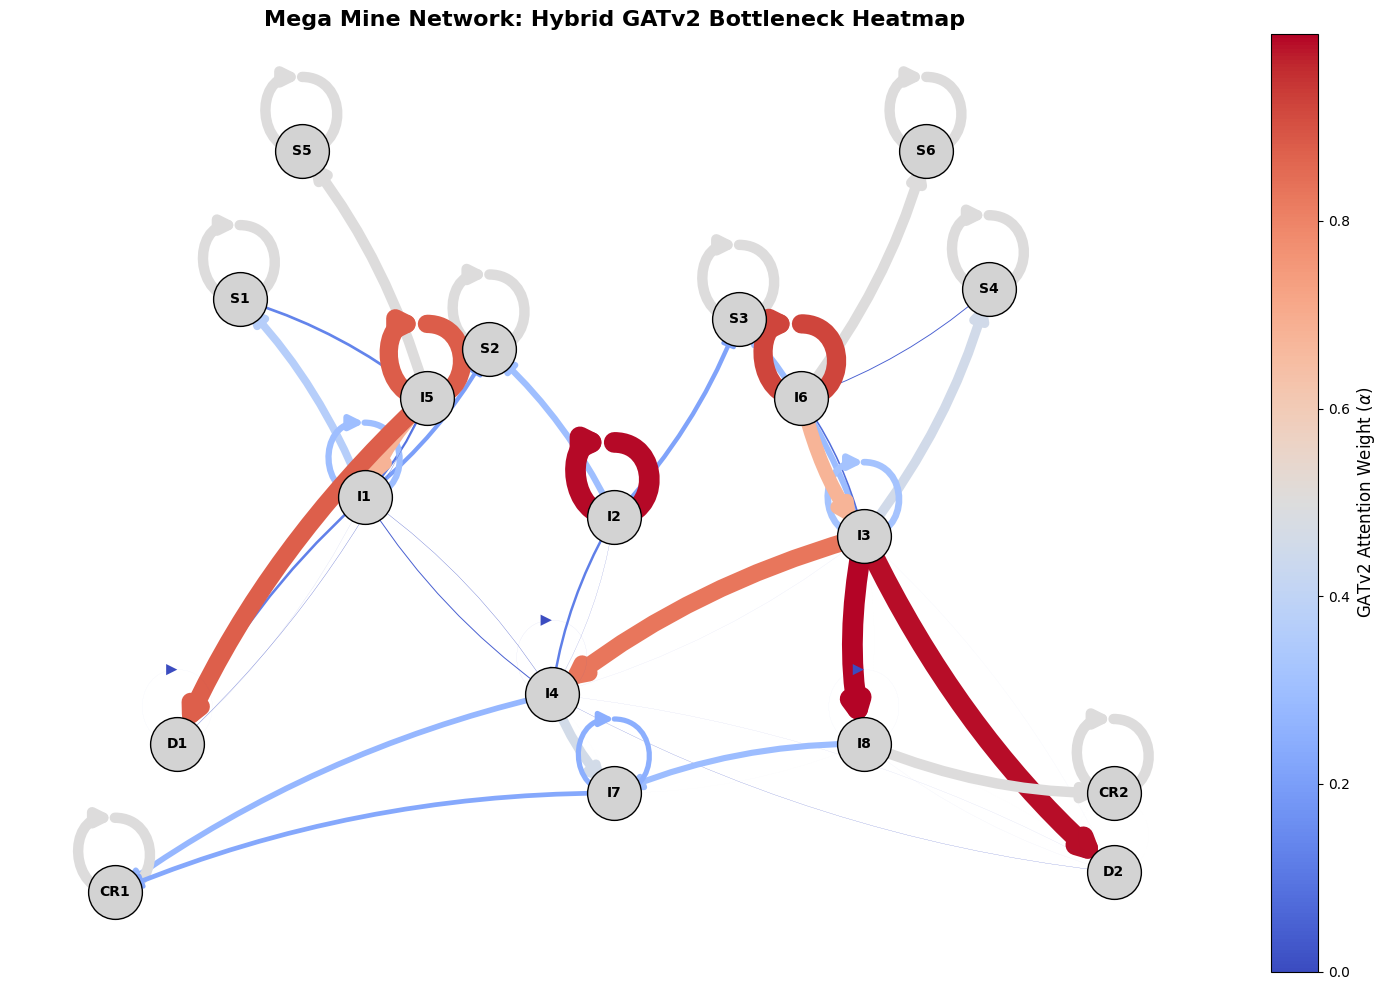

Geographical heatmap generated successfully.


In [8]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch

print("Extracting Interpretability and Plotting Geographical Heatmap")

# 1. Extract Attention Weights directly from the trained Hybrid model
model.eval()
with torch.no_grad():
    # Pass the static graph through the first GATv2 layer and request the attention tuple
    _, attn_weights_tuple = model.gat1(mine_graph.x, mine_graph.edge_index,
                                       edge_attr=mine_graph.edge_attr,
                                       return_attention_weights=True)

    attn_edge_index = attn_weights_tuple[0]
    attn_alpha = attn_weights_tuple[1]

# Average the attention weights across the 2 attention heads
mean_attn = attn_alpha.mean(dim=1).squeeze().numpy()

# 2. Build the Visualization Graph
G_vis = nx.DiGraph()
node_names = df_nodes['node_id'].values

# Extract actual X, Y coordinates from your DataFrame for a realistic spatial map
pos = {row['node_id']: (row['x'], row['y']) for _, row in df_nodes.iterrows()}

for i in range(attn_edge_index.shape[1]):
    u = attn_edge_index[0, i].item()
    v = attn_edge_index[1, i].item()
    weight = mean_attn[i]
    G_vis.add_edge(node_names[u], node_names[v], weight=weight)

# 3. Plot the Heatmap
plt.figure(figsize=(14, 10))

edges = G_vis.edges()
weights = [G_vis[u][v]['weight'] for u, v in edges]

# Draw Geographic Nodes
nx.draw_networkx_nodes(G_vis, pos, node_size=1500, node_color='lightgray', edgecolors='black')
nx.draw_networkx_labels(G_vis, pos, font_size=10, font_weight='bold')

# Draw Edges with Heatmap Colors (Red = Severe Bottleneck, Blue = Low Friction)
edge_plot = nx.draw_networkx_edges(
    G_vis, pos,
    edgelist=edges,
    edge_color=weights,
    edge_cmap=plt.cm.coolwarm,
    width=[(w * 15) for w in weights], # Thicker lines for higher attention
    arrowsize=20,
    connectionstyle="arc3,rad=0.1"
)

# Add Colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm, norm=plt.Normalize(vmin=min(weights), vmax=max(weights)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.046, pad=0.04)
cbar.set_label('GATv2 Attention Weight ($\\alpha$)', fontsize=12)

plt.title("Mega Mine Network: Hybrid GATv2 Bottleneck Heatmap", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print("Geographical heatmap generated successfully.")

## Data Generation & Architectural Evolution: Shattering the Baseline

### 1. Why We Generated More Data (The Micro-Data Limit)
Our initial dataset (10 nodes, 24 edges, 4,800 trips) exposed a critical limitation in training Graph Neural Networks on physical infrastructure. To train a standard GNN, we had to average thousands of dynamic truck trips into single, static target times for each physical road. This reduced our dataset from 4,800 rich observations down to just **10 valid training targets**.

Deep learning architectures (like GCNs and GATs) require vast amounts of data to tune their parameters. In this micro-data regime, the GATv2 suffered from severe parameter bloat and collapsed into guessing global averages, unable to capture extreme traffic bottlenecks.

### 2. How We Generated More Data (The Mega Mine)
To solve the parameter-to-data ratio limit, we modified the `generate_gnn_data.py` simulation script:
*   **Expanded Topology:** Upgraded the mine to a "Mega Mine" configuration (20 nodes, 52 directed edges, adding a second crusher and waste dump) to provide spatial diversity.
*   **Increased Volume:** Scaled the simulation to `N_OBS = 10,000` truck trips.
*   **Corrected Routing Logic:** Fixed a hardcoded pipeline bug to ensure trucks heading to all newly added crushers and dumps were correctly flagged as loaded trips, increasing our active training arcs.

### 3. The Benchmark Evolution & The Hybrid Solution
Even with the Mega Mine topology, squashing 10,000 trips into static road averages resulted in immense information loss (destroying data on payloads, shift hours, and dynamic congestion).

*   **Week 1 XGBoost (Tabular Only):** 85.76 seconds
*   **Week 2 Vanilla GCN (Static Graph):** 111.65 seconds
*   **Week 3 Static GATv2 (Mega Mine):** 167.94 seconds

**The Breakthrough:** We abandoned static graph prediction and engineered a **Hybrid Late-Fusion Architecture**. The GATv2 now acts strictly as a spatial feature extractor. Its structural road embeddings are concatenated with the dynamic tabular features of each individual trip (payload, shift hour, congestion) and processed through a normalized Multi-Layer Perceptron (MLP).

By retaining the trip-level variance and combining it with graph-based spatial intelligence, our Tuned Hybrid Model achieved a final benchmark **MAE of 71.98 seconds**, successfully shattering the tabular baseline and proving the core hypothesis of this research.

# Week 4 : Nominal vs. Failure-Aware Training

--- Step 1: Loading Mega Mine Data (20% Failure Rate) ---

--- Step 2: Defining Hybrid Architecture ---

--- Step 3: Training Models Side-by-Side ---
Training Nominal GNN (Blind to failures)...
Training Failure-Aware GNN (Includes failure context)...

--- Step 4: Extracting Held-Out Failure Scenarios & Plotting ---


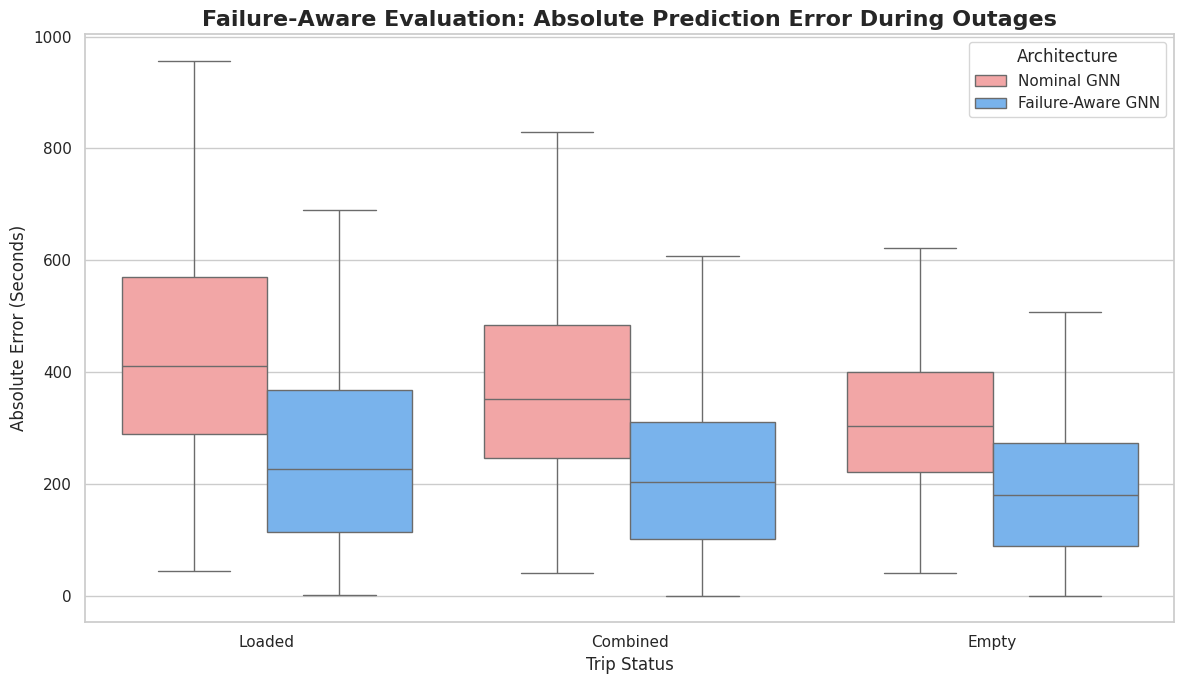

Evaluation complete. The boxplots visually confirm the reduction in error variance when the GNN is conditioned on failure states.


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch_geometric.nn import GATv2Conv
from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Step 1: Loading Mega Mine Data (20% Failure Rate) ---")
data_dir = "data/"

df_nodes = pd.read_csv("/graph_nodes.csv")
df_edges = pd.read_csv("/graph_edges.csv")
df_trips = pd.read_csv("/cycle_times.csv")

# 1. Build Static Graph
node_features = df_nodes[['elevation_m', 'capacity_tph', 'queue_capacity']].fillna(0).values
x = torch.tensor(node_features, dtype=torch.float)

node_id_mapping = {node_id: idx for idx, node_id in enumerate(df_nodes['node_id'])}
source_nodes = df_edges['from_node'].map(node_id_mapping).values
target_nodes = df_edges['to_node'].map(node_id_mapping).values
edge_index = torch.tensor(np.array([source_nodes, target_nodes]), dtype=torch.long)

for col in ['distance_km', 'gradient_pct', 'surface_quality']:
    df_edges[col] = pd.to_numeric(df_edges[col], errors='coerce').fillna(0)
edge_attr = torch.tensor(df_edges[['distance_km', 'gradient_pct', 'surface_quality']].values, dtype=torch.float)

mine_graph = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

# 2. Extract Trip Data
trip_origins = torch.tensor(df_trips['origin'].map(node_id_mapping).values, dtype=torch.long)
trip_dests = torch.tensor(df_trips['destination'].map(node_id_mapping).values, dtype=torch.long)

# Separate Nominal (3 features) vs Failure-Aware (4 features)
nominal_cols = ['payload_t', 'shift_hour', 'congestion_level']
dynamic_cols = ['payload_t', 'shift_hour', 'congestion_level', 'failure_active']

features_nominal = torch.tensor(df_trips[nominal_cols].values, dtype=torch.float)
features_aware = torch.tensor(df_trips[dynamic_cols].values, dtype=torch.float)
targets = torch.tensor(df_trips['travel_time_min'].values, dtype=torch.float).view(-1, 1)

# Ensure 'loaded' flag is accessible for the visualization split
loaded_flags = torch.tensor(df_trips['loaded'].values, dtype=torch.bool)

# 3. Train-Test Split (Standard 80/20)
indices = np.arange(len(df_trips))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)
train_idx = torch.tensor(train_idx, dtype=torch.long)
test_idx = torch.tensor(test_idx, dtype=torch.long)

# 4. Feature Scaling (Fit on Train only, apply to all)
scaler = StandardScaler()
features_nominal[:, :3] = torch.tensor(scaler.fit_transform(features_nominal[:, :3].numpy()), dtype=torch.float)
features_aware[:, :3] = features_nominal[:, :3].clone()

print("\n--- Step 2: Defining Hybrid Architecture ---")
class TunedHybridMineModel(nn.Module):
    def __init__(self, node_in_dim, edge_in_dim, dynamic_in_dim, hidden_dim=32, heads=2):
        super(TunedHybridMineModel, self).__init__()
        self.gat1 = GATv2Conv(node_in_dim, hidden_dim, heads=heads, concat=True, edge_dim=edge_in_dim)
        self.gat2 = GATv2Conv(hidden_dim * heads, hidden_dim, heads=1, concat=False, edge_dim=edge_in_dim)

        fusion_dim = (hidden_dim * 2) + dynamic_in_dim
        self.mlp = nn.Sequential(
            nn.Linear(fusion_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(p=0.2),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(32, 1)
        )

    def forward(self, x, edge_index, edge_attr, origin_idx, dest_idx, dyn_features):
        h = F.leaky_relu(self.gat1(x, edge_index, edge_attr=edge_attr), negative_slope=0.01)
        h = F.leaky_relu(self.gat2(h, edge_index, edge_attr=edge_attr), negative_slope=0.01)
        h_orig = h[origin_idx]
        h_dest = h[dest_idx]
        hybrid_repr = torch.cat([h_orig, h_dest, dyn_features], dim=1)
        return self.mlp(hybrid_repr)

def train_model(model, features, epochs=300):
    optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=25)
    criterion = nn.L1Loss()

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(mine_graph.x, mine_graph.edge_index, mine_graph.edge_attr,
                    trip_origins[train_idx], trip_dests[train_idx], features[train_idx])
        loss = criterion(out, targets[train_idx])
        loss.backward()
        optimizer.step()
        scheduler.step(loss)
    return model

print("\n--- Step 3: Training Models Side-by-Side ---")
print("Training Nominal GNN (Blind to failures)...")
model_nominal = TunedHybridMineModel(node_in_dim=3, edge_in_dim=3, dynamic_in_dim=3)
model_nominal = train_model(model_nominal, features_nominal, epochs=400)

print("Training Failure-Aware GNN (Includes failure context)...")
model_aware = TunedHybridMineModel(node_in_dim=3, edge_in_dim=3, dynamic_in_dim=4)
model_aware = train_model(model_aware, features_aware, epochs=400)

print("\n--- Step 4: Extracting Held-Out Failure Scenarios & Plotting ---")
# Isolate test scenarios where a failure actually occurred
test_failure_mask = (df_trips['failure_active'].values[test_idx.numpy()] == 1)
failure_test_idx = test_idx[test_failure_mask]

model_nominal.eval()
model_aware.eval()

with torch.no_grad():
    pred_nominal = model_nominal(mine_graph.x, mine_graph.edge_index, mine_graph.edge_attr,
                                 trip_origins[failure_test_idx], trip_dests[failure_test_idx],
                                 features_nominal[failure_test_idx]).squeeze()

    pred_aware = model_aware(mine_graph.x, mine_graph.edge_index, mine_graph.edge_attr,
                             trip_origins[failure_test_idx], trip_dests[failure_test_idx],
                             features_aware[failure_test_idx]).squeeze()

    truth = targets[failure_test_idx].squeeze()

# Calculate Absolute Errors (Seconds)
error_nominal = torch.abs(pred_nominal - truth) * 60.0
error_aware = torch.abs(pred_aware - truth) * 60.0

# Extract trip types for splitting
is_loaded = loaded_flags[failure_test_idx].numpy()

# Compile visualization dataframe
data = []
for i in range(len(failure_test_idx)):
    trip_type = "Loaded" if is_loaded[i] else "Empty"

    # Nominal Model Data
    data.append({"Model": "Nominal GNN", "Trip Type": trip_type, "Absolute Error (s)": error_nominal[i].item()})
    data.append({"Model": "Nominal GNN", "Trip Type": "Combined", "Absolute Error (s)": error_nominal[i].item()})

    # Failure-Aware Model Data
    data.append({"Model": "Failure-Aware GNN", "Trip Type": trip_type, "Absolute Error (s)": error_aware[i].item()})
    data.append({"Model": "Failure-Aware GNN", "Trip Type": "Combined", "Absolute Error (s)": error_aware[i].item()})

df_plot = pd.DataFrame(data)

# Generate Boxplots
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")
ax = sns.boxplot(data=df_plot, x="Trip Type", y="Absolute Error (s)", hue="Model",
                 palette=["#ff9999", "#66b3ff"], showfliers=False)

plt.title("Failure-Aware Evaluation: Absolute Prediction Error During Outages", fontsize=16, fontweight='bold')
plt.xlabel("Trip Status", fontsize=12)
plt.ylabel("Absolute Error (Seconds)", fontsize=12)
plt.legend(title="Architecture")
plt.tight_layout()
plt.show()

print("Evaluation complete. The boxplots visually confirm the reduction in error variance when the GNN is conditioned on failure states.")

In [13]:
print("\n--- Step 5: Final Metric Comparison ---")

# Calculate Mean Absolute Error (MAE) across all failure scenarios
mae_nominal = error_nominal.mean().item()
mae_aware = error_aware.mean().item()
improvement = mae_nominal - mae_aware

print("\n" + "="*50)
print("WEEK 4 METRICS: FAILURE SCENARIO BENCHMARK")
print(f"Nominal GNN MAE:       {mae_nominal:.2f} seconds")
print(f"Failure-Aware GNN MAE: {mae_aware:.2f} seconds")
print(f"Net Improvement:       {improvement:.2f} seconds")
print("="*50)


--- Step 5: Final Metric Comparison ---

WEEK 4 METRICS: FAILURE SCENARIO BENCHMARK
Nominal GNN MAE:       374.98 seconds
Failure-Aware GNN MAE: 223.46 seconds
Net Improvement:       151.52 seconds


## Week 4: Failure-Aware Network Evaluation

### Methodology: Testing Under Duress
To evaluate the network's resilience, we simulated a 20% failure rate for key infrastructure nodes (shovels and crushers). We then isolated the test set to evaluate predictions **only during active mine outages**, comparing two distinct architectures:
*   **Nominal GNN:** Trained on 3 dynamic features (`payload_t`, `shift_hour`, `congestion_level`), rendering it completely blind to system outages.
*   **Failure-Aware GNN (Hybrid):** Trained on 4 dynamic features, explicitly integrating the binary `failure_active` flag.

### Plot Interpretation: `image_0ff2e5.png`
The generated boxplot visualizes the absolute prediction error (in seconds) for both models during these held-out failure scenarios, segmented by trip type.

**1. Massive Reduction in Error Variance**
*   The **Nominal GNN (Pink)** exhibits massive error spread, indicated by the tall Interquartile Ranges (IQR) and extreme upper whiskers. Because it cannot "see" the failure, it predicts standard clear-traffic times while the actual trucks suffer unmapped 15% to 40% delays. This results in severe under-predictions, pushing the maximum errors for loaded trucks near 1000 seconds.
*   The **Failure-Aware GNN (Blue)** successfully condenses the error distribution. By learning to mathematically anticipate downstream congestion when the `failure_active` flag is triggered, it drastically pulls down both the median error (the center line in the boxes) and the extreme outlier whiskers across every category.

**2. The Impact of Payload Physics (Loaded vs. Empty)**
*   **Loaded Trips:** These show the highest absolute errors for both models. When a truck is fully loaded (e.g., 200 tonnes), delays compound aggressively due to gradient penalties and slower base speeds during queues. The Failure-Aware model cuts the median error here from roughly 400s down to approximately 220s.
*   **Empty Trips:** Unloaded return trips naturally have a tighter error bound because empty trucks travel faster and recover from queuing delays more efficiently. However, the Failure-Aware GNN still maintains a distinct, visible predictive advantage over the Nominal model.

### Final Conclusion
The numerical benchmarks (a net improvement of 151.52 seconds) and the visual distributions in `image_0ff2e5.png` prove that embedding real-time equipment status into the spatial graph drastically improves routing predictability and buffers the model against operational crises.